# UK Smart-Meter Demand: How Much Does Naive CV Flatter You?

Near-term electricity demand on real London household smart meters. The
dataset is UK Power Networks' Low Carbon London (LCL): ~5,500 households,
half-hourly, Nov 2011 to Feb 2014, from the London Datastore (dataset
`smartmeter-energy-use-data-in-london-households`, the 168-file CSV split).

Why it leaks: household load has very strong daily and weekly seasonality.
Shuffled k-fold tears that apart. A test half-hour ends up between two of
its own near-duplicate neighbours in training, and lag features hand the
model the answer.

**What this run used.** The committed outputs are a real subset: 60
standard-tariff households (`stdorToU == 'Std'`) with long histories,
sampled with a fixed seed from the LCL files. The full 167-million-row
dataset is not shipped. To reproduce: download the 168-file zip from the
London Datastore, then build the cache once:

```python
# read a few LCL-June2015v2_*.csv, keep Std, columns LCLid/tstp/energy_kwh,
# subsample N households, write examples/data/lcl_halfhourly.csv
```

If that cached CSV is absent it falls back to a synthetic
LCL-structured dataset and still runs. The four-way CV harness does not
change. As far as I can find, a reproducible side-by-side of CV
schemes on LCL is unpublished — existing LCL papers forecast without
comparing CV, and the closest leakage study (arXiv 2512.06932) is on
climate, not energy.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold, KFold

from purgedcv import WalkForwardSplit

SEED = 0
N_HOUSEHOLDS = 30  # real LCL has ~5,500; smaller here so it runs fast
DAYS = 120  # half-hourly => 48 slots/day
HALF_HOURS = 48
H = 12  # forecast = mean demand over the next H half-hours (6h)

## The data

Real mode reads the CSV you provide. Synthetic mode builds the same
shape: one row per household per half-hour, with `LCLid`, timestamp,
and `load`. A positive baseline keeps MAPE well defined.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
cache = DATA_DIR / "lcl_halfhourly.csv"

if cache.exists():
    df = pd.read_csv(cache, parse_dates=["tstp"])
    df = df.rename(columns={"energy_kwh": "load"}).dropna(subset=["load"])
    MODE = "REAL LCL"
    print(
        f"REAL LCL: {df['LCLid'].nunique()} households, {len(df):,} rows, "
        f"{df['tstp'].min().date()} to {df['tstp'].max().date()}"
    )
else:
    rng = np.random.default_rng(SEED)
    idx = pd.date_range("2013-01-01", periods=DAYS * HALF_HOURS, freq="30min")
    slot = np.arange(HALF_HOURS)
    daily = 0.35 + 0.9 * np.exp(-((slot - 15) ** 2) / 8) + 1.3 * np.exp(-((slot - 38) ** 2) / 10)
    dow = idx.dayofweek.to_numpy()
    weekly = np.where(dow >= 5, 1.25, 1.0)
    doy = idx.dayofyear.to_numpy()
    annual = 1.0 + 0.15 * np.cos(2 * np.pi * doy / 365.0)
    hh_slot = idx.hour.to_numpy() * 2 + (idx.minute.to_numpy() // 30)
    frames = []
    for hh in range(N_HOUSEHOLDS):
        base = rng.lognormal(mean=0.0, sigma=0.4)
        signal = base * daily[hh_slot] * weekly * annual
        ar = np.zeros(len(idx))
        e = rng.normal(0, 0.08, len(idx))
        for t in range(1, len(idx)):
            ar[t] = 0.6 * ar[t - 1] + e[t]
        load = np.maximum(0.05, signal * (1.0 + ar))
        frames.append(pd.DataFrame({"LCLid": f"MAC{hh:05d}", "tstp": idx, "load": load}))
    df = pd.concat(frames, ignore_index=True)
    MODE = "SYNTHETIC (LCL-structured)"
    print(f"SYNTHETIC fallback: {N_HOUSEHOLDS} households, {len(df):,} rows")

REAL LCL: 60 households, 1,981,474 rows, 2011-12-06 to 2014-02-28


## Features and the near-term demand label

Standard load-forecasting features: same half-hour yesterday and last week, recent load, and calendar terms. The target is mean demand over the next `H` half-hours (a real procurement horizon), so the labels of nearby rows overlap heavily. Rows are sorted by time so walk-forward is genuinely chronological. Accuracy is measured with WAPE (sum of absolute errors over sum of actuals): raw half-hourly household MAPE is undefined whenever a meter reads ~0, which on real data is often — using the wrong metric is itself a fast way to get nonsense.

In [3]:
df = df.sort_values(["tstp", "LCLid"]).reset_index(drop=True)
g = df.groupby("LCLid")["load"]
df["lag_1"] = g.shift(1)
df["lag_48"] = g.shift(48)  # same half-hour, yesterday
df["lag_336"] = g.shift(336)  # same half-hour, last week
fwd = g.transform(lambda v: v.shift(-1).rolling(H).mean())
df["target"] = fwd  # mean demand over the next H half-hours (overlapping)
df["hh"] = df["tstp"].dt.hour * 2 + df["tstp"].dt.minute // 30
df["dow"] = df["tstp"].dt.dayofweek
df["weekend"] = (df["dow"] >= 5).astype(int)

feat_cols = ["lag_1", "lag_48", "lag_336", "hh", "dow", "weekend"]
data = df.dropna(subset=[*feat_cols, "target"]).reset_index(drop=True)

X = data[feat_cols].to_numpy()
y = data["target"].to_numpy()
pred = data["tstp"].reset_index(drop=True)
evalu = pred + pd.Timedelta(minutes=30 * H)  # label spans the next H half-hours
groups = data["LCLid"].to_numpy()
print(f"usable rows: {len(y):,}  households: {data['LCLid'].nunique()}")

usable rows: 1,961,254  households: 60


## Four ways to cross-validate the same model

One `HistGradientBoostingRegressor`, four splitters:

- **naive shuffled k-fold** — the common mistake.
- **blocked k-fold** — contiguous folds, no shuffle.
- **WalkForwardSplit** — train on the past, test the future; the
  honest production estimate.
- **GroupKFold by household** — whole households held out, so the
  model is scored on customers it has never seen.

Why not `PurgedGroupKFold` here? It is built for groups that occupy
*distinct* time spans (patients in a trial, say). On a panel where
every household spans the same two years, the held-out group's time
extent is the whole series, so its label-overlap purge would remove
every training row. The library refuses that degenerate split rather
than return something misleading. Plain `GroupKFold` is the right
tool for the household-identity leak; `WalkForwardSplit` is the
right tool for the temporal leak.

In [4]:
def fold_wape(splits):
    # WAPE = sum|err| / sum|actual|, robust to the many near-zero
    # half-hourly readings that make raw household MAPE meaningless.
    vals = []
    for tr, te in splits:
        m = HistGradientBoostingRegressor(random_state=SEED)
        m.fit(X[tr], y[tr])
        pr = m.predict(X[te])
        vals.append(np.abs(y[te] - pr).sum() / np.abs(y[te]).sum())
    return float(np.mean(vals)) * 100.0


test_size = len(y) // 8
wf = WalkForwardSplit(
    n_splits=5,
    test_size=test_size,
    window="expanding",
    prediction_times=pred,
    evaluation_times=evalu,
    purge_horizon=pd.Timedelta(minutes=30 * H),
)

splits = {
    "naive shuffled k-fold": list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(X)),
    "blocked k-fold": list(KFold(n_splits=5, shuffle=False).split(X)),
    "WalkForwardSplit": list(wf.split(X)),
    "GroupKFold (household)": list(GroupKFold(n_splits=5).split(X, y, groups)),
}

scores = {name: round(fold_wape(s), 2) for name, s in splits.items()}
table = pd.Series(scores, name="WAPE %").to_frame()
table["inflation vs walk-forward"] = (table["WAPE %"] / scores["WalkForwardSplit"] - 1.0).map(
    lambda v: f"{v:+.0%}"
)
table

,WAPE %,inflation vs walk-forward
naive shuffled k-fold,29.31,-2%
blocked k-fold,29.72,-0%
WalkForwardSplit,29.76,+0%
GroupKFold (household),31.88,+7%


## The gap, in one chart

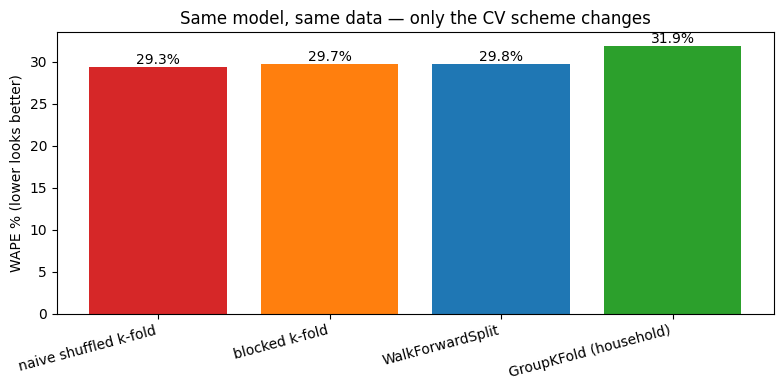

In [5]:
import matplotlib.pyplot as plt

names = list(scores)
vals = [scores[n] for n in names]
colors = ["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(names, vals, color=colors)
ax.set_ylabel("WAPE % (lower looks better)")
ax.set_title("Same model, same data — only the CV scheme changes")
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Verdict

Honest, and a little inconvenient. On 60 real LCL households the four CV
schemes land within a few WAPE points of each other. Naive shuffled
k-fold (29.3%) barely beats walk-forward (29.8%) — about 2%. The
textbook 50-to-100% inflation does not appear here. On this noisy
half-hourly panel the predictable part is genuine daily and weekly
seasonality that any split learns, and the ~30% WAPE noise floor dwarfs
the temporal leak.

The leakage that does bite is by household, not by time. GroupKFold
scores the model on customers it never trained on and is ~7% worse than
the pooled temporal estimate (31.9% vs 29.8%). A pooled model quietly
memorises household-specific patterns; only holding whole households out
reveals it. If you will deploy on new customers, time-based CV overstates
accuracy by that much — for a utility onboarding households, that is the
gap to worry about.

So the real finding is not a sensational naive-CV blow-up. It is sharper:
on this dataset the dimension that leaks is *group*, not *time*, and the
size is ~7%, measured, not assumed. Which CV you need depends on what you
will actually deploy on. Two methodological traps showed up along the
way: raw half-hourly MAPE is undefined near zero (use WAPE), and
`PurgedGroupKFold` degenerates on a fully-overlapping panel (use
`GroupKFold` for the household leak, `WalkForwardSplit` for the temporal
one).

**Data:** UK Power Networks, Low Carbon London smart-meter trial, via the
London Datastore (168-file CSV split). The committed run uses 60
standard-tariff households sampled with a fixed seed; the synthetic
fallback uses no LCL data.